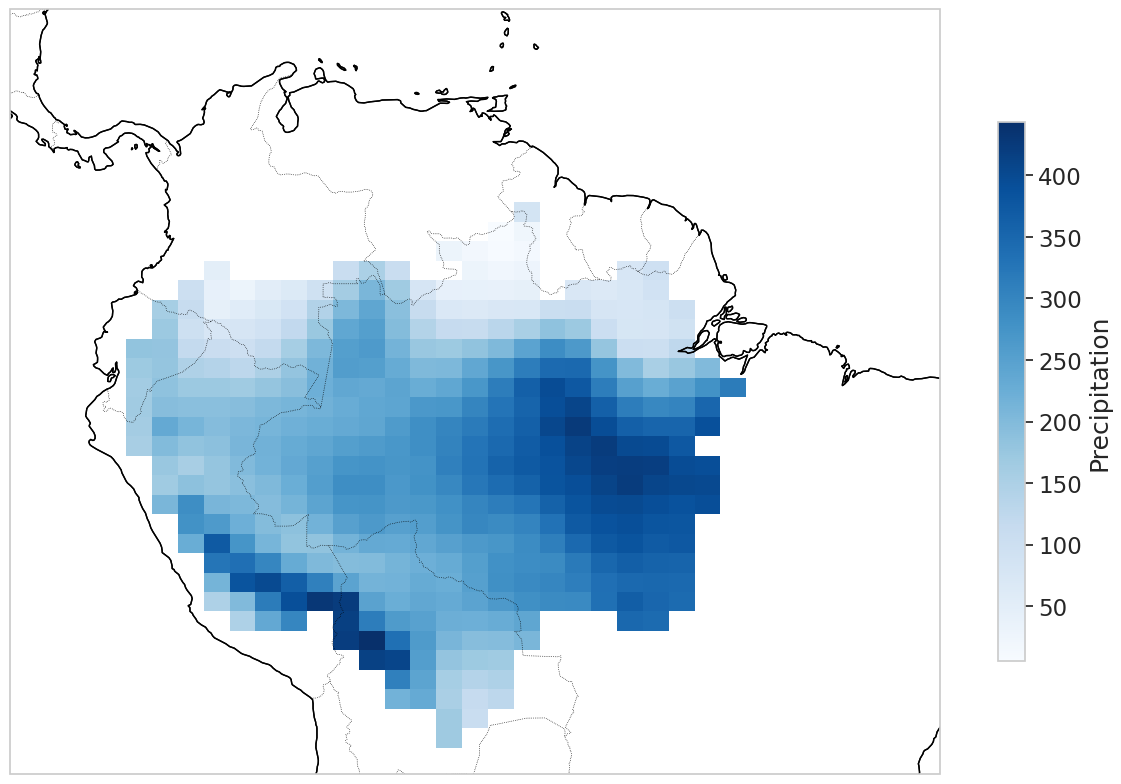

Karten erfolgreich gespeichert in: precipitation_maps


In [3]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

def plot_precipitation_map(filepath: str, scenario_decade: str):
    """
    Plottet eine Karte des Niederschlags (Precipitation) ohne überlappende Grid-Zellen.
    """
    # 1. Daten laden
    ds = xr.open_dataset(filepath)
    
    # 2. 1D-Daten in ein 2D-Raster (Grid) umwandeln
    # pcolormesh braucht eine 2D-Matrix, aber unsere NetCDF hat die Knoten als 1D-Liste.
    df = pd.DataFrame({
        'lon': ds["lon"].values,
        'lat': ds["lat"].values,
        'prec': ds["prec"].values
    })
    
    # pivot_table baut uns das perfekte 2D-Schachbrett-Muster auf
    grid = df.pivot_table(index='lat', columns='lon', values='prec')
    
    lon_grid = grid.columns.values
    lat_grid = grid.index.values
    prec_matrix = grid.values 
    
    # 3. Plotting-Design einstellen
    sns.set(font_scale=1.5)
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(15, 10))
    
    # 4. Karten-Projektion (PlateCarree ist Standard für Längen-/Breitengrade)
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Koordinatenbereich für den Amazonas/Südamerika (275 bis 320 ist 85°W bis 40°W)
    ax.set_extent([275, 320, -22, 15], crs=ccrs.PlateCarree())
    
    # Küstenlinien und Grenzen hinzufügen
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.coastlines('50m')
    
    # 5. Der magische Befehl gegen Überlappungen: pcolormesh
    # Wir übergeben nun die sauberen 2D-Gitter, die wir oben mit Pandas erstellt haben.
    mesh = ax.pcolormesh(
        lon_grid, 
        lat_grid, 
        prec_matrix, 
        cmap='Blues', 
        shading='auto', 
        transform=ccrs.PlateCarree()
    )
    
    # 6. Farbskala (Colorbar) hinzufügen
    cbar = plt.colorbar(mesh, ax=ax, label='Precipitation', shrink=0.7)
    
    # 7. Speichern
    output_dir = 'precipitation_maps'
    os.makedirs(output_dir, exist_ok=True)
    
    png_path = os.path.join(output_dir, f'prec_map_{scenario_decade}.png')
    pdf_path = os.path.join(output_dir, f'prec_map_{scenario_decade}.pdf')
    
    #plt.savefig(png_path, bbox_inches='tight', dpi=300)
    #plt.savefig(pdf_path, bbox_inches='tight')
    
    plt.show()
    plt.close()
    
    print(f"Karten erfolgreich gespeichert in: {output_dir}")

if __name__ == "__main__":
    # Beispielaufruf (Passe den Dateipfad an deine Daten an!)
    plot_precipitation_map("../1-data/water/scenario_ssp245_decade2030_month01.nc", scenario_decade="ssp245_2030")
    pass

In [2]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import seaborn as sns

# Globale Variablen für das Skript
CARTOPY_AVAILABLE = True
CONNECTION_THRESHOLD = 1.1514  # Passe diesen Wert an deinen gewünschten Threshold an

# --- Amazon Map Setup Functions ---
def setup_amazon_map(fig_size=(12, 8)):
    """Create an Amazon map with coastlines and borders.

    Args:
        fig_size (tuple): Size of the figure.

    Returns:
        tuple: (fig, ax1, ax2, kwargs) - The figure, the two axes, and the transform kwargs.

    """
    fig = plt.figure(figsize=fig_size)

    if CARTOPY_AVAILABLE:
        ax = plt.axes(projection=ccrs.PlateCarree())

        ax.set_extent([-81, -48, -22.5, 7.5], crs=ccrs.PlateCarree())

        COASTLINES = cfeature.NaturalEarthFeature(
            'physical', 'coastline', '50m', edgecolor='black', facecolor='none'
        )
        BORDERS = cfeature.NaturalEarthFeature(
            'cultural', 'admin_0_countries', '50m', edgecolor='black', facecolor='none'
        )

        ax.add_feature(COASTLINES, linewidth=1)
        ax.add_feature(BORDERS, linestyle='-', linewidth=0.5)

        kwargs = {'transform': ccrs.PlateCarree()}

        return fig, ax, kwargs

    else:
        print("Cartopy not available. Returning standard axes.")
        ax = plt.axes()
        kwargs = {}
        return fig, ax, kwargs


def setup_double_amazon_map(fig_size=(22, 8)):
    """Create an Amazon map with two subplots side by side.

    Args:
        fig_size (tuple): Size of the figure.

    Returns:
        tuple: (fig, ax1, ax2, kwargs) - The figure, the two axes, and the transform kwargs.

    """
    if CARTOPY_AVAILABLE:
        projection = ccrs.PlateCarree()
        kwargs = {'transform': projection}

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size,
                                       subplot_kw={'projection': projection})

        COASTLINES = cfeature.NaturalEarthFeature(
            'physical', 'coastline', '50m', edgecolor='black', facecolor='none'
        )
        BORDERS = cfeature.NaturalEarthFeature(
            'cultural', 'admin_0_countries', '50m', edgecolor='black', facecolor='none'
        )

        ax1.set_extent([-81, -48, -22.5, 7.5], crs=projection)
        ax1.add_feature(COASTLINES, linewidth=1)
        ax1.add_feature(BORDERS, linestyle='-', linewidth=0.5)

        ax2.set_extent([-81, -48, -22.5, 7.5], crs=projection)
        ax2.add_feature(COASTLINES, linewidth=1)
        ax2.add_feature(BORDERS, linestyle='-', linewidth=0.5)

        return fig, ax1, ax2, kwargs

    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)
        print("Cartopy not available. Returning standard axes.")
        kwargs = {}
        return fig, ax1, ax2, kwargs

Erstelle zweiseitigen Overview-Plot (Fig 1) für SSP245 (2030 vs 2099)...
 -> Jahr 2030: 1731 Pfeile über dem Threshold (1.1514) gefunden.
 -> Jahr 2099: 1475 Pfeile über dem Threshold (1.1514) gefunden.
Vergleichsplot erfolgreich gespeichert unter: Plots/Fig1_Overview_Network_Comparison_245.png


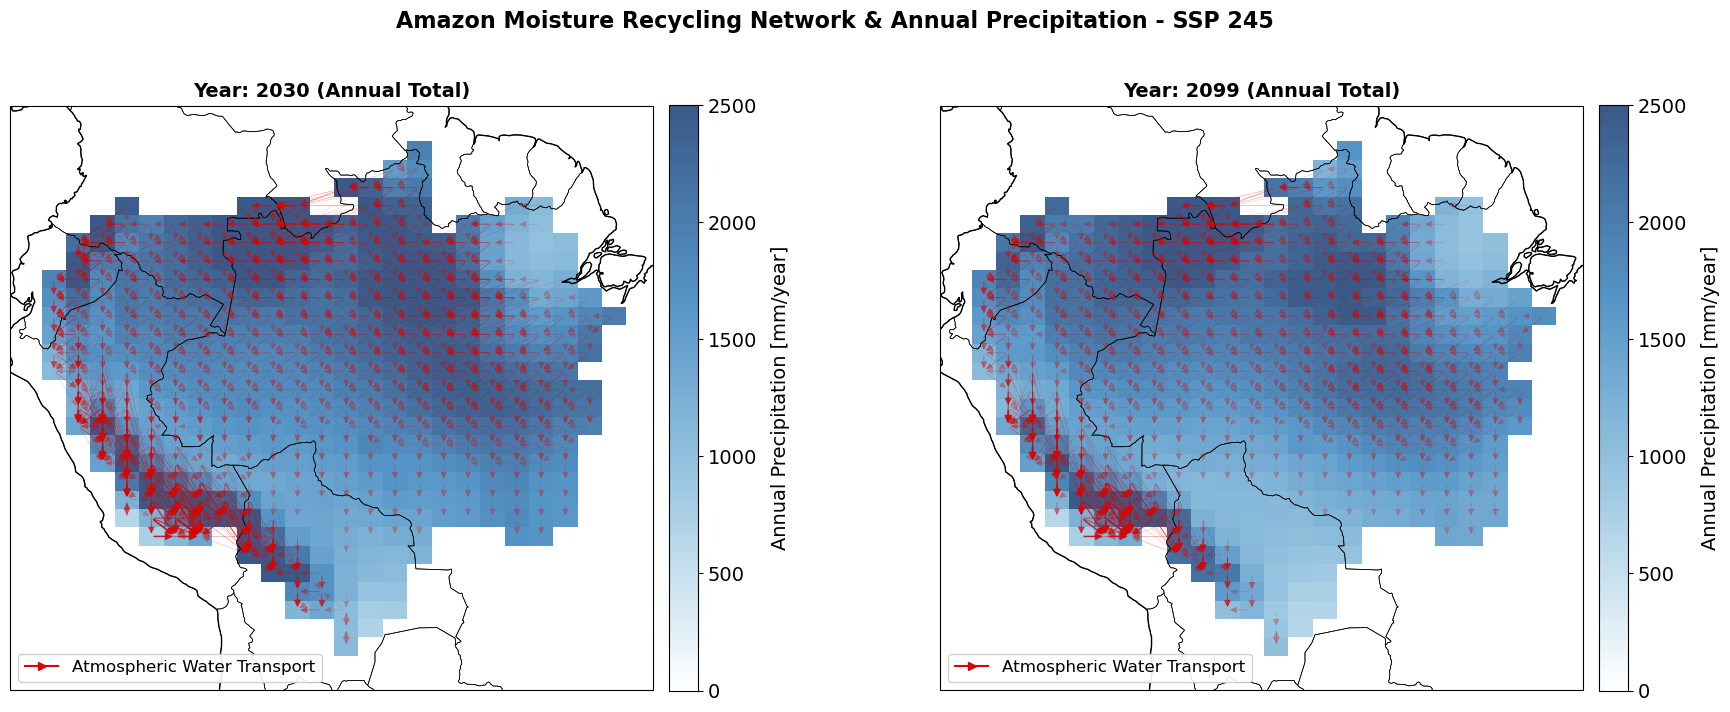

In [6]:
from matplotlib import colors
import xarray as xr


def plot_paper_fig1_overview(scenario: int, max_linewidth: float = 2.5) -> None:
    """
    Creates Figure 1 for the paper: A side-by-side comparison of the first year (2030)
    and the last year (2099) showing total annual precipitation (background)
    and averaged transport routes (arrows).
    Both color scales and arrow thickness are globally scaled for accurate comparison.
    """
    year_start = 2030
    year_end = 2099

    print(f"Erstelle zweiseitigen Overview-Plot (Fig 1) für SSP{scenario} ({year_start} vs {year_end})...")

    # Hilfsfunktion, um die akkumulierten Jahresdaten zu laden
    def load_annual_data(year):
        prec_sum = None
        network_sum = None
        lon = None
        lat = None
        filepath = f"../2-pre-processing/pre-processed-data/water_Raw/scenario_ssp{scenario}_decade{year}_Raw.nc"
        with xr.open_dataset(filepath) as ds:
            prec_sum = ds["prec"].values.copy()
            network_sum = ds["network"].values.copy() / 12
            lon = ds["lon"].values
            lat = ds["lat"].values
        return prec_sum, network_sum, lon, lat

    # 1. Daten für beide Jahre laden
    prec_start, network_start, lon_np, lat_np = load_annual_data(year_start)
    prec_end, network_end, _, _ = load_annual_data(year_end)

    # 2. Globale Max-Werte bestimmen (für konsistente Farbskalen UND Pfeildicken)
    # global_vmax_prec = max(np.percentile(prec_start, 90), np.percentile(prec_end, 90))
    # global_max_weight = max(np.max(network_start), np.max(network_end))
    global_max_weight = 90 / 12

    # 3. Double-Map Setup aufrufen
    fig, ax1, ax2, kwargs = setup_double_amazon_map(fig_size=(22, 8))
    fig.suptitle(f"Amazon Moisture Recycling Network & Annual Precipitation - SSP {scenario}",
                 fontsize=16, fontweight="bold", y=0.98)

    # Listen für die iterative Bearbeitung beider Subplots
    years = [year_start, year_end]
    axes = [ax1, ax2]
    prec_data = [prec_start, prec_end]
    network_data = [network_start, network_end]

    for ax, year, prec_vals, net_vals in zip(axes, years, prec_data, network_data):

        # --- NEU: 1D in 2D Raster umwandeln für pcolormesh ---
        df_plot = pd.DataFrame({
            'lon': lon_np,
            'lat': lat_np,
            'prec': prec_vals
        })
        # pivot_table baut uns das perfekte 2D-Schachbrett-Muster auf
        grid = df_plot.pivot_table(index='lat', columns='lon', values='prec')

        cmap_data = np.loadtxt("../ScientificColourMaps8/devon/devon.txt")
        cmap_color = colors.LinearSegmentedColormap.from_list('CBname', cmap_data)
        cmap_color = cmap_color.reversed()

        vibrant_colors = ["#ffffff", "#33ccff", "#0066ff", "#000080"]
        vibrant_cmap = colors.LinearSegmentedColormap.from_list("VibrantBlue", vibrant_colors, N=256)

        elegant_colors = [ "#ffffff", "#89bedc", "#2b7bba", "#08306b"]
        elegant_cmap = colors.LinearSegmentedColormap.from_list("ElegantBlue", elegant_colors, N=256)
        
        # 4. Hintergrund plotten (Gesamter Jahresniederschlag) mit pcolormesh
        sc = ax.pcolormesh(
            grid.columns.values,
            grid.index.values,
            grid.values,
            cmap=elegant_cmap, #"Blues"
            vmin=0,
            vmax=2500,  # = global_vmax_prec # Einheitliche für alle Szenarios
            alpha=0.8,
            shading='auto',
            **kwargs
        )

        # Colorbar für jedes Subplot
        cbar = fig.colorbar(sc, ax=ax, shrink=0.95,pad=0.02)
        # Zahlen an der Colorbar kleiner machen
        cbar.ax.tick_params(labelsize=14)
        # Beschriftung der Colorbar größer machen
        cbar.set_label("Annual Precipitation [mm/year]", fontsize=14, labelpad=10)

        # 5. Verbindungen filtern
        i_indices, j_indices = np.where(net_vals > CONNECTION_THRESHOLD)

        print(f" -> Jahr {year}: {len(i_indices)} Pfeile über dem Threshold ({CONNECTION_THRESHOLD}) gefunden.")

        # 6. Pfeile in das jeweilige Subplot einzeichnen
        if len(i_indices) > 0:
            for i, j in zip(i_indices, j_indices):
                if i == j:  # Selbstverbindungen ignorieren
                    continue

                start_point = (lon_np[j], lat_np[j])
                end_point = (lon_np[i], lat_np[i])
                weight = net_vals[i, j]

                # Skalierung von Dicke und Transparenz basierend auf dem GLOBALEN Maximum
                lw = max(0.2, (weight / global_max_weight) * max_linewidth)
                alpha_val = max(0.2, min(0.9, weight / global_max_weight * 1.5))

                ax.annotate(
                    "",
                    xy=end_point,
                    xytext=start_point,
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color="#D30808",  
                        linewidth=lw * 0.8,   # Angepasste Linienbreite
                        alpha=alpha_val,
                        mutation_scale=10,    # Angepasste Pfeilspitzengröße
                        shrinkA=2,            # Zieht den Pfeil am Start minimal ein
                        shrinkB=2             # Zieht den Pfeil am Ziel minimal ein
                    ),
                    **kwargs
                )

        # 6.5 Custom Legend für die Pfeile
        # Wir erstellen einen Dummy-Pfeil für die Legende
        arrow_legend = mlines.Line2D([], [], color='#D30808', marker='>',
                                     markersize=6, label='Atmospheric Water Transport',
                                     linewidth=1.5)
        # Unten links ist bei Südamerika-Karten meistens der Pazifik (viel leerer Platz)
        ax.legend(handles=[arrow_legend], loc="lower left", fontsize=12, framealpha=0.9)

        # Subplot-Beschriftung
        ax.set_title(f"Year: {year} (Annual Total)", fontsize=14, fontweight="bold")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, linestyle="--", alpha=0.4)

    # 7. Speichern & Schließen
    out_dir = "Plots/"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"Fig1_Overview_Network_Comparison_{scenario}.png")

    plt.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f"Vergleichsplot erfolgreich gespeichert unter: {out_path}")

    plt.show()


if __name__ == "__main__":
    # Beispielaufruf für SSP 245
    plot_paper_fig1_overview(scenario=245, max_linewidth=2.5)

Erstelle historischen Niederschlags-Plot aus: ../3-processing/processed-data/timeseries_historical/historical_spatial_average_per_cell.csv
Historischer Plot erfolgreich gespeichert unter: Plots/Fig_Historical_Precipitation.png


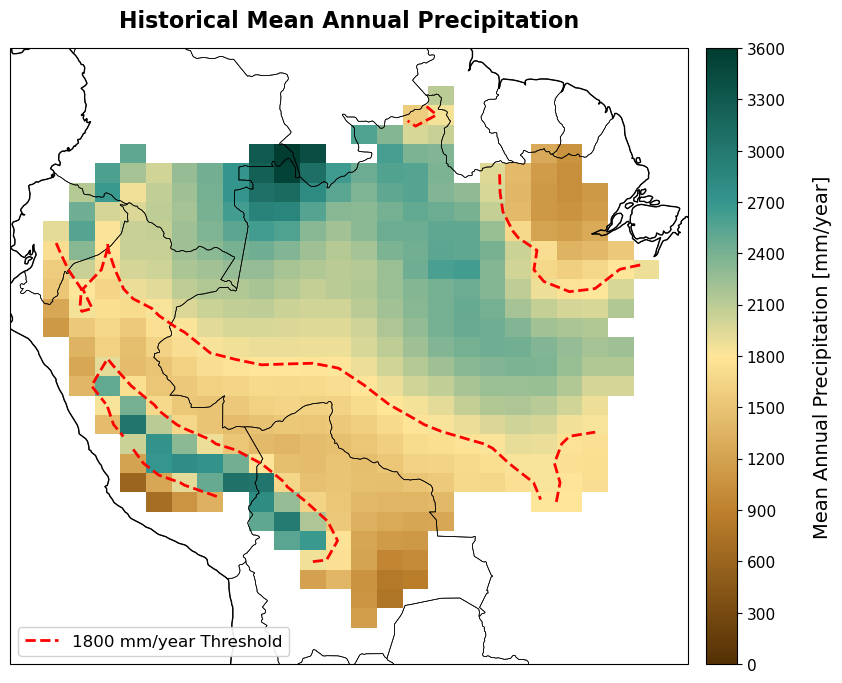

Erstelle historischen Niederschlags-Plot aus: ../3-processing/processed-data/timeseries_historical/historical_spatial_average_per_cell.csv
Historischer Plot erfolgreich gespeichert unter: Plots/Fig_Historical_Precipitation_Deviation.png


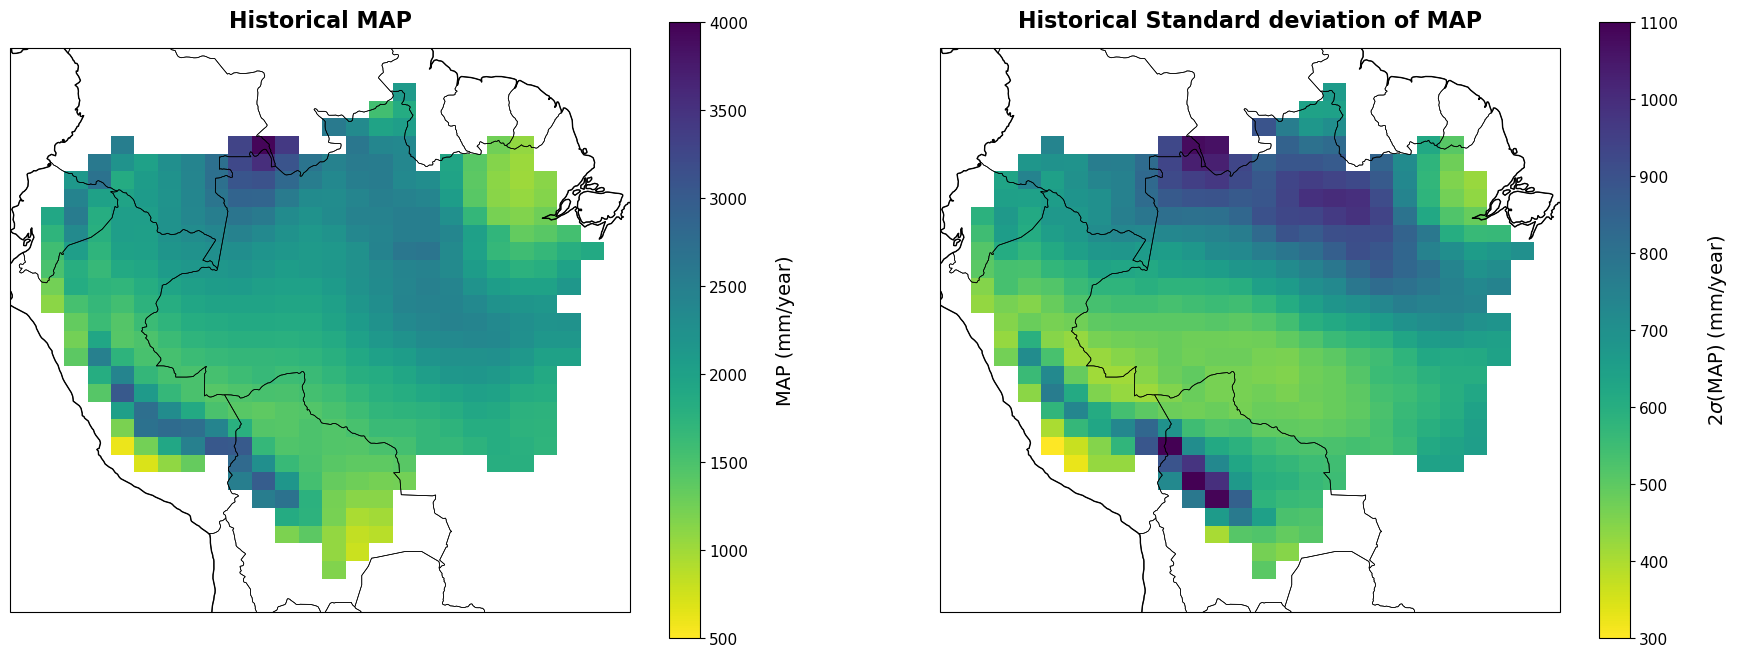

In [19]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns


def plot_historical_precipitation_map(filepath: str) -> None:
    """
    Plottet die historischen Niederschlagsdaten aus der CSV, um die räumliche Varianz
    (und die Abweichung vom 1800mm Schwellenwert) zu demonstrieren.
    """
    print(f"Erstelle historischen Niederschlags-Plot aus: {filepath}")

    # 1. Daten laden
    df = pd.read_csv(filepath)

    # 2. In 2D-Raster umwandeln
    grid = df.pivot_table(index='lat', columns='lon', values='mean_annual_prec')

    # 3. Map Setup aufrufen
    fig, ax, kwargs = setup_amazon_map(fig_size=(12, 8))
    ax.set_title("Historical Mean Annual Precipitation", fontsize=16, fontweight="bold", pad=15)

    # 4. Symmetrische Colormap Normierung (Fix für die "großen Farbsprünge")
    # Wir zwingen die Skala auf 0 bis 3600. Dadurch liegt 1800 exakt mathematisch in der Mitte.
    # Der Farbverlauf ist nun streng linear: 500mm Unterschied sehen überall im Plot gleich aus.
    vmin = 0
    vmax = 3600
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # --- NEU: Weichere, kontrastreichere Colormap ---
    # Mehr Zwischenschritte für weichere Übergänge (N=256 erzwingt stufenlosen Verlauf)
    cmap_colors = [
        "#543005",  # 0 mm (Dunkelbraun)
        "#bf812d",  # 900 mm (Mittelbraun)
        "#ffe699",  # 1800 mm (Helles Gelb - Kipppunkt)
        "#35978f",  # 2700 mm (Türkis)
        "#003c30"   # 3600 mm (Dunkelgrün)
    ]

    custom_cmap = mcolors.LinearSegmentedColormap.from_list("BrYlBG_Smooth", cmap_colors, N=256)

    # 5. Hintergrund plotten mit pcolormesh
    sc = ax.pcolormesh(
        grid.columns.values,
        grid.index.values,
        grid.values,
        cmap=custom_cmap,
        norm=norm,
        shading='auto',
        **kwargs
    )

    # 6. Konturlinie bei exakt 1800mm ziehen
    # Hilft optisch stark zu sehen, wo die theoretische "Kipppunkt"-Grenze verläuft
    cs = ax.contour(
        grid.columns.values,
        grid.index.values,
        grid.values,
        levels=[1800],
        colors='red',
        linewidths=2,
        linestyles='dashed',
        **kwargs
    )
    
    # Legende für die Konturlinie hinzufügen
    contour_legend = mlines.Line2D([], [], color='red', linestyle='dashed', 
                                   linewidth=2, label='1800 mm/year Threshold')
    ax.legend(handles=[contour_legend], loc="lower left", fontsize=12, framealpha=0.9)

    # 7. Colorbar formatieren
    # Ticks in sauberen 300er-Schritten, damit 1800 exakt getroffen wird und gut ablesbar ist
    cbar = fig.colorbar(sc, ax=ax, shrink=1.00, pad=0.02, ticks=np.arange(0, 3601, 300))
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label("Mean Annual Precipitation [mm/year]", fontsize=14, labelpad=20)

    # 8. Speichern
    out_dir = "Plots/"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "Fig_Historical_Precipitation.png")

    #plt.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f"Historischer Plot erfolgreich gespeichert unter: {out_path}")

    plt.show()


def plot_historical_precipitation_deviation(filepath: str) -> None:
    """
    Plottet die historischen Niederschlagsdaten aus der CSV, um die räumliche Varianz
    (und die Abweichung vom 1800mm Schwellenwert) zu demonstrieren.
    """
    print(f"Erstelle historischen Niederschlags-Plot aus: {filepath}")

    # 1. Daten laden
    df = pd.read_csv(filepath)

    # 2. In 2D-Raster umwandeln
    grid1 = df.pivot_table(index='lat', columns='lon', values='mean_annual_prec')
    grid2 = df.pivot_table(index='lat', columns='lon', values='std_annual_prec')


    # 3. Map Setup aufrufen
    fig, ax1, ax2, kwargs = setup_double_amazon_map(fig_size=(22, 8))
    ax1.set_title("Historical MAP", fontsize=16, fontweight="bold", pad=15)
    ax2.set_title("Historical Standard deviation of MAP", fontsize=16, fontweight="bold", pad=15)

    # 4. Symmetrische Colormap Normierung (Fix für die "großen Farbsprünge")
    # Wir zwingen die Skala auf 0 bis 3600. Dadurch liegt 1800 exakt mathematisch in der Mitte.
    # Der Farbverlauf ist nun streng linear: 500mm Unterschied sehen überall im Plot gleich aus.

    # --- NEU: Weichere, kontrastreichere Colormap ---
    # Mehr Zwischenschritte für weichere Übergänge (N=256 erzwingt stufenlosen Verlauf)
    cmap_colors = [
        "#543005",  # 0 mm (Dunkelbraun)
        "#bf812d",  # 900 mm (Mittelbraun)
        "#ffe699",  # 1800 mm (Helles Gelb - Kipppunkt)
        "#35978f",  # 2700 mm (Türkis)
        "#003c30"   # 3600 mm (Dunkelgrün)
    ]

    custom_cmap = mcolors.LinearSegmentedColormap.from_list("BrYlBG_Smooth", cmap_colors, N=256)

    # 5. Hintergrund plotten mit pcolormesh
    sc1 = ax1.pcolormesh(
        grid1.columns.values,
        grid1.index.values,
        grid1.values,
        cmap="viridis_r",
        vmin=500,
        vmax=4000,
        shading='auto',
        **kwargs
    )

    sc2 = ax2.pcolormesh(
        grid2.columns.values,
        grid2.index.values,
        grid2.values,
        cmap="viridis_r",
        vmin=300,
        vmax=1100,
        shading='auto',
        **kwargs
    )
    
    # 7. Colorbar formatieren
    # Ticks in sauberen 300er-Schritten, damit 1800 exakt getroffen wird und gut ablesbar ist
    cbar1 = fig.colorbar(sc1, ax=ax1, shrink=1.00)
    cbar1.ax.tick_params(labelsize=11)
    cbar1.set_label("MAP (mm/year)", fontsize=14, labelpad=20)

    cbar2 = fig.colorbar(sc2, ax=ax2, shrink=1.00)
    cbar2.ax.tick_params(labelsize=11)
    cbar2.set_label(r"$2\sigma(\text{MAP})$ (mm/year)", fontsize=14, labelpad=20)

    # 8. Speichern
    out_dir = "Plots/"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "Fig_Historical_Precipitation_Deviation.png")

    #plt.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f"Historischer Plot erfolgreich gespeichert unter: {out_path}")

    plt.show()


if __name__ == "__main__":
    # Neuer Plot: Historische Varianz des Niederschlags aufzeigen
    hist_filepath = "../3-processing/processed-data/timeseries_historical/historical_spatial_average_per_cell.csv"
    plot_historical_precipitation_map(hist_filepath)
    plot_historical_precipitation_deviation(hist_filepath)


Erstelle Clustering-Plot aus: ../3-processing/processed-data/metrics_Raw/network_metrics_ssp245_decade2030_Raw.csv
Clustering Plot erfolgreich gespeichert unter: Plots/Fig2_Clustering_Coefficient.png


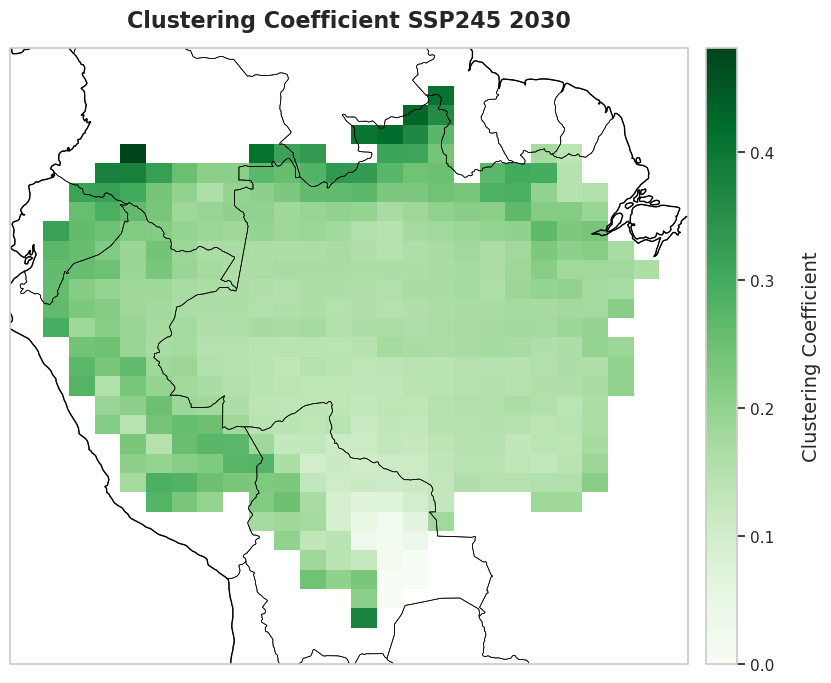

In [ ]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns

CONNECTION_THRESHOLD = 1.1514  # Passe diesen Wert an deinen gewünschten Threshold an


def plot_clustering_map(scenario: int, year: int, month=None, deforest: str = "Raw") -> None:
    """
    Plottet den Clustering-Koeffizienten für ein bestimmtes Szenario und Jahr.
    Filtert die Daten automatisch auf den globalen CONNECTION_THRESHOLD.
    """
    if month is None:
        filepath = f"../3-processing/processed-data/metrics_{deforest}/network_metrics_ssp{scenario}_decade{year}_{deforest}.csv"
    else:
        filepath = f"../3-processing/processed-data/metrics_{deforest}/network_metrics_ssp{scenario}_decade{year}_{month:02d}_{deforest}.csv"
    
    print(f"Erstelle Clustering-Plot aus: {filepath}")

    # 1. Daten laden
    df = pd.read_csv(filepath)

    # --- NEU: Nur den gewünschten Threshold filtern ---
    # Wir runden auf 4 Nachkommastellen, um "Float-Ungenauigkeiten" beim Vergleich 
    # (z.B. 1.151400000001 != 1.1514) sicher abzufangen.
    df = df[df['threshold'].round(4) == round(CONNECTION_THRESHOLD, 4)]
    
    if df.empty:
        print(f"WARNUNG: Keine Daten für den Threshold {CONNECTION_THRESHOLD} in {filepath} gefunden!")
        return

    # 2. In 2D-Raster umwandeln (jetzt haben wir garantiert nur noch 1 Wert pro Koordinate)
    grid = df.pivot_table(index='lat', columns='lon', values='clustering')

    # 3. Map Setup aufrufen
    fig, ax, kwargs = setup_amazon_map(fig_size=(12, 8))
    if month is not None:
        ax.set_title(f"Clustering Coefficient SSP{scenario} {year}-{month:02d}", fontsize=16, fontweight="bold", pad=15)
    else:
        ax.set_title(f"Clustering Coefficient SSP{scenario} {year}", fontsize=16, fontweight="bold", pad=15)

    # 4. Symmetrische Colormap Normierung
    vmin = 0
    #vmax = 1
    norm = mcolors.Normalize(vmin=vmin)

    # 5. Hintergrund plotten mit pcolormesh
    sc = ax.pcolormesh(
        grid.columns.values,
        grid.index.values,
        grid.values,
        cmap=plt.get_cmap('Greens'),
        norm=norm,
        shading='auto',
        **kwargs
    )

    # 7. Colorbar formatieren
    # Ticks bis 1.1 laufen lassen, damit der Strich bei 1.0 gezeichnet wird!
    cbar = fig.colorbar(sc, ax=ax, shrink=1.00, pad=0.02, ticks=np.arange(0, 1.1, 0.1))
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label("Clustering Coefficient", fontsize=14, labelpad=20)

    # 8. Speichern
    out_dir = "Plots/"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "Fig2_Clustering_Coefficient.png")

    # plt.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f"Clustering Plot erfolgreich gespeichert unter: {out_path}")

    plt.show()


if __name__ == "__main__":
    # Neuer Plot: Historische Varianz des Niederschlags aufzeigen
    plot_clustering_map(scenario=245, year=2030, month=None, deforest="Raw")

Erstelle FFLs-Plot aus: ../3-processing/processed-data/metrics_Raw/network_metrics_ssp245_decade2030_Raw.csv
FFLs Plot erfolgreich gespeichert unter: Plots/Fig2_FFLs.png


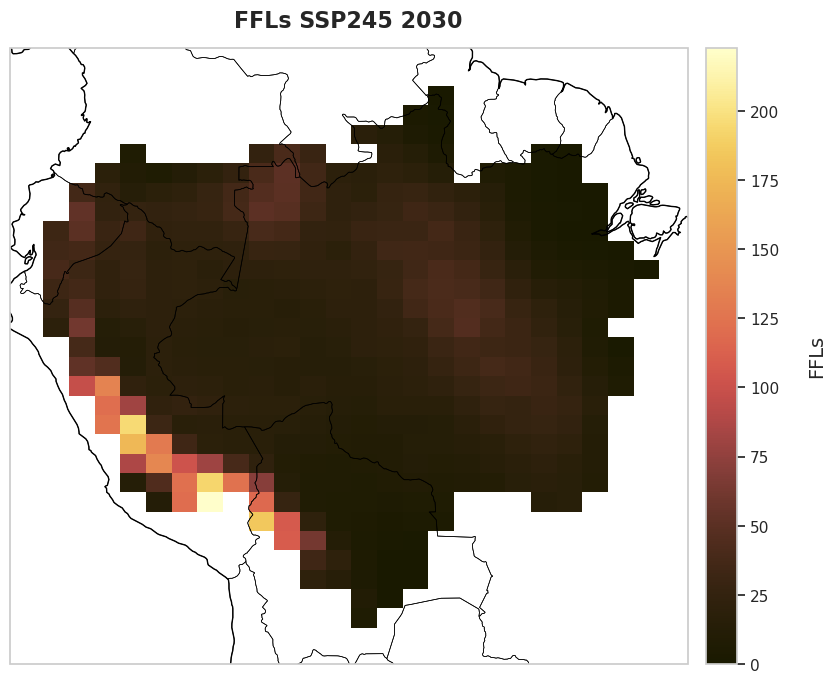

In [31]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import matplotlib.colors as colors
import seaborn as sns

CONNECTION_THRESHOLD = 1.1514  # Passe diesen Wert an deinen gewünschten Threshold an


def plot_ffls_map(scenario: int, year: int, month=None, deforest: str = "Raw") -> None:
    """
    Plottet die FFLs für ein bestimmtes Szenario und Jahr.
    Filtert die Daten automatisch auf den globalen CONNECTION_THRESHOLD.
    """
    if month is None:
        filepath = f"../3-processing/processed-data/metrics_{deforest}/network_metrics_ssp{scenario}_decade{year}_{deforest}.csv"
    else:
        filepath = f"../3-processing/processed-data/metrics_{deforest}/network_metrics_ssp{scenario}_decade{year}_{month:02d}_{deforest}.csv"
    
    print(f"Erstelle FFLs-Plot aus: {filepath}")

    # 1. Daten laden
    df = pd.read_csv(filepath)

    # --- NEU: Nur den gewünschten Threshold filtern ---
    # Wir runden auf 4 Nachkommastellen, um "Float-Ungenauigkeiten" beim Vergleich 
    # (z.B. 1.151400000001 != 1.1514) sicher abzufangen.
    df = df[df['threshold'].round(4) == round(CONNECTION_THRESHOLD, 4)]
    
    if df.empty:
        print(f"WARNUNG: Keine Daten für den Threshold {CONNECTION_THRESHOLD} in {filepath} gefunden!")
        return

    # 2. In 2D-Raster umwandeln (jetzt haben wir garantiert nur noch 1 Wert pro Koordinate)
    grid = df.pivot_table(index='lat', columns='lon', values='ffl')

    # 3. Map Setup aufrufen
    fig, ax, kwargs = setup_amazon_map(fig_size=(12, 8))
    if month is not None:
        ax.set_title(f"FFLs SSP{scenario} {year}-{month:02d}", fontsize=16, fontweight="bold", pad=15)
    else:
        ax.set_title(f"FFLs SSP{scenario} {year}", fontsize=16, fontweight="bold", pad=15)

    # 4. Symmetrische Colormap Normierung
    vmin = 0
    # vmax = 120
    norm = mcolors.Normalize(vmin=vmin) #, vmax=vmax)

    cmap_data = np.loadtxt("../ScientificColourMaps8/tokyo/tokyo.txt")
    cmap_color = colors.LinearSegmentedColormap.from_list('CBname', cmap_data)
    inverted_cmap = cmap_color.reversed()

    cmap_data = np.loadtxt("../ScientificColourMaps8/lajolla/lajolla.txt")
    cmap_color = colors.LinearSegmentedColormap.from_list('CBname', cmap_data)

    # 5. Hintergrund plotten mit pcolormesh
    sc = ax.pcolormesh(
        grid.columns.values,
        grid.index.values,
        grid.values,
        cmap = cmap_color,
        norm=norm,
        shading='auto',
        **kwargs
    )

    # 7. Colorbar formatieren
    # Ticks bis 1.1 laufen lassen, damit der Strich bei 1.0 gezeichnet wird!
    cbar = fig.colorbar(sc, ax=ax, shrink=1.00, pad=0.02) #, ticks=np.arange(0, 120, 10))
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label("FFLs", fontsize=14, labelpad=20)

    # 8. Speichern
    out_dir = "Plots/"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "Fig2_FFLs.png")

    # plt.savefig(out_path, bbox_inches='tight', dpi=300)
    print(f"FFLs Plot erfolgreich gespeichert unter: {out_path}")

    plt.show()


if __name__ == "__main__":
    # Neuer Plot: Historische Varianz des Niederschlags aufzeigen
    plot_ffls_map(scenario=245, year=2030, month=None, deforest="Raw")